In [1]:
from functions import one_sentence_chunks, text_to_ipa_chunks


with open("story1.txt", "r", encoding="utf-8") as f:
    text = f.read()

text_chunked = one_sentence_chunks(text)
ipa_chunks = text_to_ipa_chunks(text_chunked)

c:\Users\gmoha\anaconda3\envs\kokoro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\gmoha\anaconda3\envs\kokoro\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
c:\Users\gmoha\anaconda3\envs\kokoro\Lib\site-packages\torch\nn\utils\weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [9]:
for i, (chunk, ipa) in enumerate(zip(text_chunked, ipa_chunks)):
    print(f"Chunk {i+1}:")
    print(f"Text: {chunk}")
    print(f"n tokens: {len(ipa)}")
    print("-" * 40)

Chunk 1:
Text: Esplorare il fondo degli oceani è un'impresa incredibilmente difficile, molto più complessa di un viaggio nello spazio.
n tokens: 127
----------------------------------------
Chunk 2:
Text: Quando un astronauta si trova nello spazio esterno, la differenza tra l'aria dentro la navicella e il vuoto fuori è minima.
n tokens: 135
----------------------------------------
Chunk 3:
Text: Negli abissi marini, invece, la situazione si ribalta completamente.
n tokens: 73
----------------------------------------
Chunk 4:
Text: Se scendiamo sul fondo della Fossa delle Marianne, che è il punto più profondo del nostro pianeta a circa undici chilometri sotto il livello del mare, il peso dell'acqua diventa schiacciante.
n tokens: 204
----------------------------------------
Chunk 5:
Text: Immaginate di dover camminare con migliaia di automobili impilate sopra la testa: questa è la forza costante che l'oceano esercita su qualunque oggetto provi a scendere fin laggiù.
n tokens: 194
------

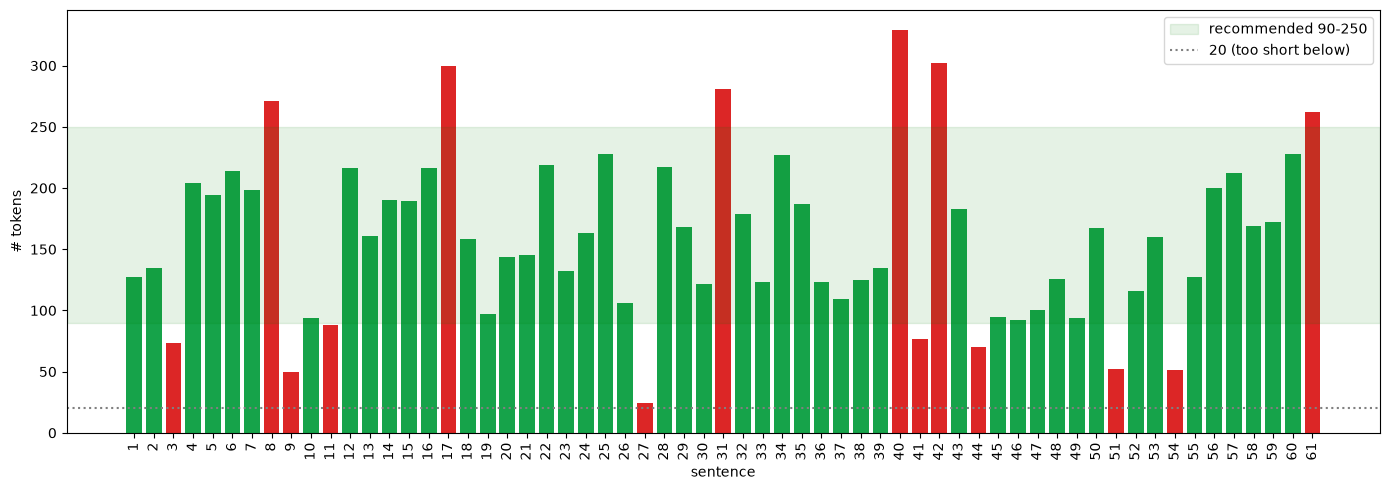

In [7]:




import pandas as pd
import matplotlib.pyplot as plt

counts = [len(ipa) for ipa in ipa_chunks]
df = pd.DataFrame({"sentence": range(1, len(counts) + 1), "n_tokens": counts})
    
colors = ["#16a34a" if 90 <= n <= 250 else "#dc2626" for n in df["n_tokens"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df["sentence"], df["n_tokens"], color=colors)

ax.axhspan(90, 250, color="green", alpha=0.1, label="recommended 90-250")
ax.axhline(20, color="gray", ls=":", label="20 (too short below)")

ax.set_xlabel("sentence")
ax.set_ylabel("# tokens")
ax.set_xticks(df["sentence"])
ax.set_xticklabels(df["sentence"], rotation=90)
ax.legend()

plt.tight_layout()
plt.show()






In [15]:
def merge_ipa_chunks(ipa_chunks, a, b, sep=" ", max_len=250):
    """
    Merge IPA chunks a..b (1-based, inclusive) into a single chunk.
    Returns a NEW list; the original is left untouched.

    ipa_chunks : list[str] from text_to_ipa_chunks()
    a, b       : sentence numbers to merge (order doesn't matter)
    sep        : what goes between merged chunks (space keeps a natural pause/boundary)
    max_len    : phoneme-token limit of the model
    """
    n = len(ipa_chunks)
    a, b = sorted((a, b))
    if not (1 <= a <= n and 1 <= b <= n):
        raise ValueError(f"Sentence numbers must be between 1 and {n}, got {a}, {b}")
    if a == b:
        print("⚠ Same sentence number given, nothing to merge.")
        return list(ipa_chunks)

    merged = sep.join(ipa_chunks[a - 1:b])
    # if len(merged) > max_len:
    #     print(f"too much : {len(merged)} tokens, no merge performed.")
    #     return list(ipa_chunks)

    return ipa_chunks[:a - 1] + [merged] + ipa_chunks[b:]


def merge_many(ipa_chunks, pairs, **kw):
    """
    Apply several merges using the ORIGINAL sentence numbers.
    e.g. merge_many(chunks, [(2, 3), (7, 9)])
    Processed from the end so earlier numbering isn't shifted.
    """
    for a, b in sorted((tuple(sorted(p)) for p in pairs), reverse=True):
        ipa_chunks = merge_ipa_chunks(ipa_chunks, a, b, **kw)
    return ipa_chunks

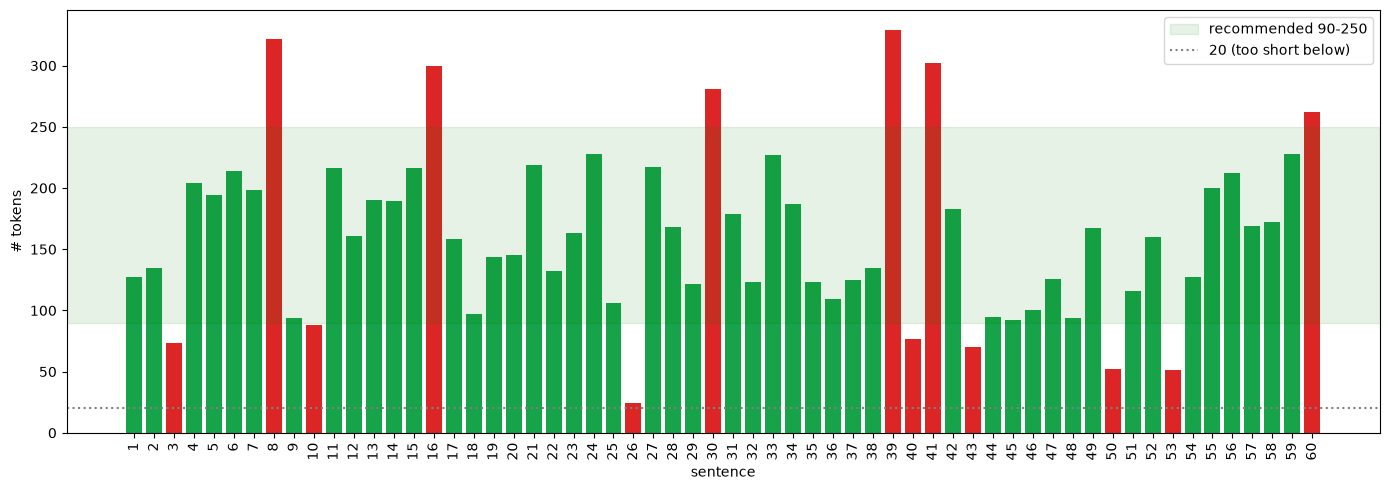

In [16]:

new_chunks = merge_many(ipa_chunks, [(8, 9)])
counts = [len(ipa) for ipa in new_chunks]
df = pd.DataFrame({"sentence": range(1, len(counts) + 1), "n_tokens": counts})
    
colors = ["#16a34a" if 90 <= n <= 250 else "#dc2626" for n in df["n_tokens"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df["sentence"], df["n_tokens"], color=colors)

ax.axhspan(90, 250, color="green", alpha=0.1, label="recommended 90-250")
ax.axhline(20, color="gray", ls=":", label="20 (too short below)")

ax.set_xlabel("sentence")
ax.set_ylabel("# tokens")
ax.set_xticks(df["sentence"])
ax.set_xticklabels(df["sentence"], rotation=90)
ax.legend()

plt.tight_layout()
plt.show()